# Using the zero-noise extrapolation error mitigation technique in Quantum Inspire

**Authors:** Jan Hemink, Marios Samiotis (m.samiotis@tudelft.nl)

**Date:** August 27, 2026

# 1. Introduction

In this tutorial notebook we will showcase the zero-noise extrapolation (ZNE) error mitigation technique with the quantum backends which exist at the [Quantum Inspire 2.0](https://www.quantum-inspire.com/) cloud services, and go through some helpful tools that were developed alongside it.

Prior to using this notebook, for optimal performance, make sure that you are running it within a customized Python 3.12 environment which includes the packages "quantuminspire" and "qiskit-quantuminspire".

For details on how to create such a Python environment, follow the installation instructions in the [README file](https://github.com/DiCarloLab-Delft/QuantumInspireUtilities/blob/main/README.md).

Useful links:
1. [Tuna Backends Operational Specifics](https://www.quantum-inspire.com/kbase/tuna-operational-specifics/)
2. [Backend Performance Dashboards](https://monitoring.qutech.support/public-dashboards/c494a21fb6b7405f850ab8f340f798ef?orgId=1&refresh=10s) [live updates]
3. [Join our Slack community!](https://join.slack.com/t/qisuperconducting/shared_invite/zt-35o7zitdh-_9QPmB53hhLy12Eat5gwWA)

First, we run the following cell in order to login to the Quantum Inspire platform. You need an account in order to login to the platform.

Please click on "Confirm" in the pop-up browser window to login.

In [ ]:
! qi login "https://api.quantum-inspire.com"

Run the following cell for all necessary library imports,

In [1]:
import numpy as np
from IPython.display import display, Image
from qiskit import QuantumCircuit, transpile
from qiskit_quantuminspire.qi_provider import QIProvider

from qi_utilities.error_mitigation.toolkit.pauli_twirling import pauli_twirl_cz
from qi_utilities.error_mitigation.toolkit.helper_functions import get_qubit_pairs, stitch_circuits
from qi_utilities.error_mitigation.noise_learning.experiments import CZPauliFidelityMeasurements
from qi_utilities.error_mitigation.noise_amplification.experiments import NoiseAmplification, ZNE
from qi_utilities.error_mitigation.noise_amplification.helper_functions import load_error_rates_from_disk, perform_ZNE

from qi_utilities.utility_functions.raw_data_processing import observable_expectation_values_Z_basis
from qi_utilities.device_simulation.simulators import NoisySimulator # use the simulator in case all backends are unavailable!

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

/Users/mariossamiotis/Documents/Repositories/QuantumInspireUtilities/qi_utilities/error_mitigation/noise_learning/experiments.py:18: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# 2. Connecting to a backend

We first connect to the Quantum Inspire provider, by running the following cell,

In [ ]:
provider = QIProvider()

The following command prints the full list of all available backends of the platform,

In [ ]:
provider.backends()

We now connect to a Tuna backend by running the following cell,

In [ ]:
backend_name = "Tuna-9"
backend = provider.get_backend(name=backend_name)

In order to avoid waiting in the queue, we can save time by using a simulator instead,

In [2]:
backend = NoisySimulator("Starmon-7")

The superconducting Tuna backends of Quantum Inspire, as well as all superconducting simulators of this repository, have as their only native two-qubit gate the CZ gate.

Therefore, for everything that follows, the error mitigation techniques are applied on individual CZ gates.

# 3. Approximating the noise of a CZ gate with a Pauli error channel $\Lambda_P$ via Pauli Twirling

<div style="text-align: center;">
  <img src="figures/2.0_figures/noisy_unitary.jpg" width="800">
</div>

Every quantum operation (denoted as $\mathcal{U}$), in a real quantum device suffers from noise, usually denoted as $\Lambda$ and referred to as the 'noise channel' associated with the operation $\mathcal{U}$. In all that follows, we follow the convention that a noisy operation $\tilde{\mathcal{U}}$ acting on two (or more) qubits $Q_i$ and $Q_j$ is described as the action of the noise channel $\Lambda$, followed by the action of the ideal operation $\mathcal{U}$ (mathematically expressed as $\tilde{\mathcal{U}} = \mathcal{U} \circ \Lambda$).

In order to mitigate errors originating from a CZ gate, we first need to describe the noise mathematically and learn it. Generally, the noise of a two-qubit gate can be very complex: it can include crosstalk and various other effects which are hard to describe with simple quantum error channels. Therefore, we resort to a technique called 'Pauli twirling', with which we approximate a general noise channel $\Lambda$ with a simpler noise channel $\Lambda_P$, which can easily be described mathematically as a Markovian noise channel which is diagonal in the Pauli basis,

$$

\Lambda_P (P_i) = f_i P_i,

$$

for an n-qubit noise channel $\Lambda_P$ acting on an n-qubit Pauli operator, with $f_i$ being a real coefficient $f_i \in [0, 1]$ called (Pauli) fidelity. When $P_i = I^{\otimes n}$, $f_{I^{\otimes n}} = 1$. For reference, an n-qubit Pauli operator $P_i$ can be written as $P_i = P_{n-1, i} \otimes P_{n-2, i} \otimes \cdots \otimes P_{1, i} \otimes P_{0, i}$, where $P_{j, i}$ is a single-qubit $i$-th Pauli operator acting on qubit $Q_j$, where $P_{j, i} \in \{I, X, Y, Z \}$.

We apply Pauli twirling on a two-qubit CZ gate by applying a random two-qubit Pauli operator $P$ before the CZ, uniformly sampled from the set of all 16 possible two-qubit Paulis $\{I, X, Y, Z \}^{\otimes 2} = \{ II, IX, IY, IZ, XI, ..., ZZ\}$, followed by the application of its conjugate $P^\prime$ right after the CZ. Here $P$ acts on qubits $Q_i$ and $Q_j$, with $P = P_i \otimes P_j$ where $P_i, P_j \in \{ \mathbb{I}, X, Y, Z \}$. After $N$ such randomizations, the results are averaged into the approximate action of the noise channel $\Lambda$ onto an ideal CZ gate.\
Here $P^\prime = \mathrm{CZ}\ P\ \mathrm{CZ}^\dagger$, so that the ideal action of the CZ remains unchanged.

<div style="text-align: center;">
  <img src="figures/2.0_figures/pauli_twirling.jpg" width="900">
</div>

Let us take a look at how this gets handled by the noise-learning functions of this module.

First we define a very simple two-qubit quantum circuit, with both qubits initialized in the ground state $|0\rangle$, with a CZ gate applied on them followed by a measurement,

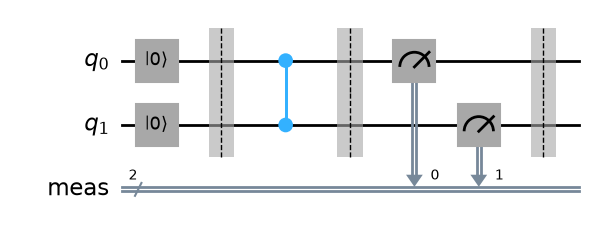

In [3]:
qc = QuantumCircuit(2)

qc.reset([0,1])
qc.barrier()
qc.cz(0,1)
qc.measure_all()
qc.barrier()
qc.draw('mpl')

Here we pass the above circuit through a function which applies Pauli twirling to the CZ gate,

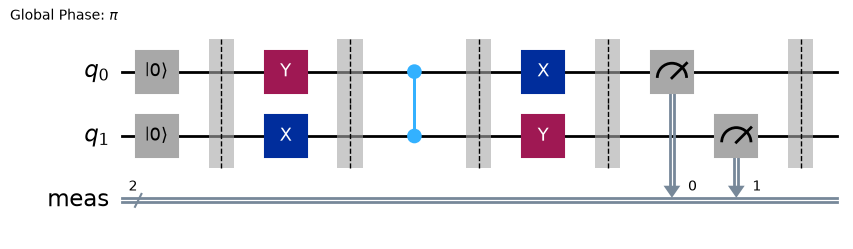

In [4]:
twirled_qc = pauli_twirl_cz(qc)
twirled_qc.draw("mpl")

The resulting circuit above is a single randomization, where $P = X_1 Y_0$ and $P^\prime = Y_1 X_0$ (this can be different when we re-execute the above cell). We can also obtain multiple randomizations at once,

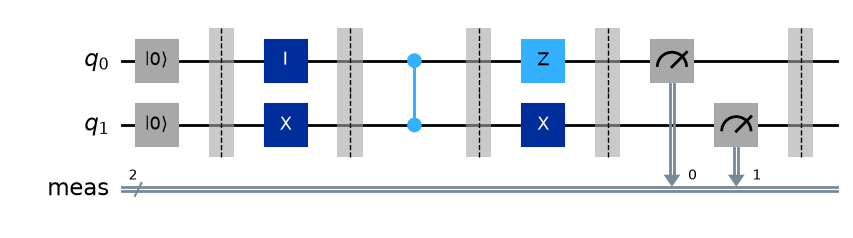

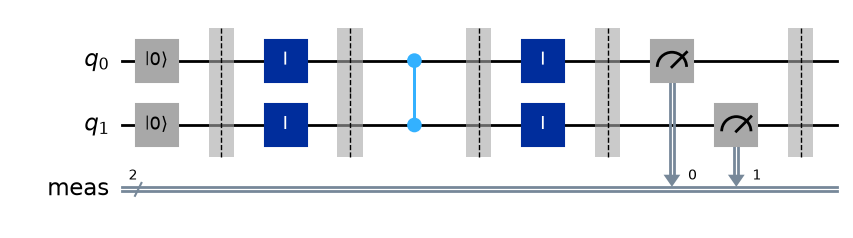

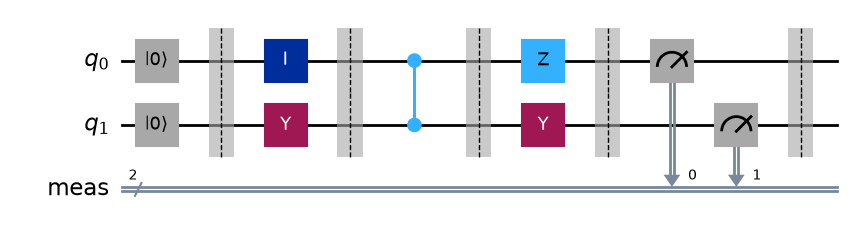

In [5]:
twirled_qc_list = pauli_twirl_cz(qc, num_circuits=3)
for circuit in twirled_qc_list:
    display(circuit.draw("mpl"))

Notice that the random two-qubit Paulis $P$ applied before the CZ are (most likely) different each time the cell is executed. We can set the seed used for the randomization, such that we obtain the same results with every application of the function `pauli_twirl_cz`,

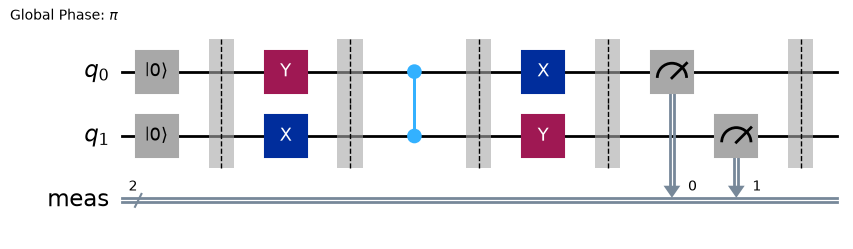

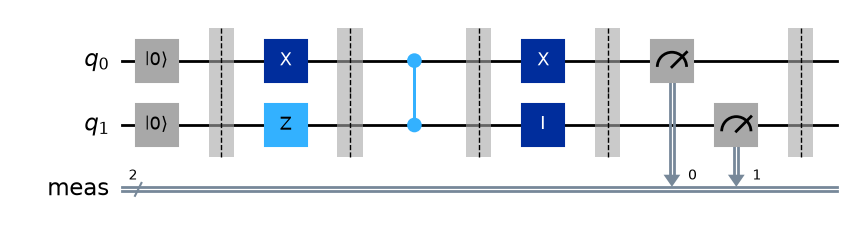

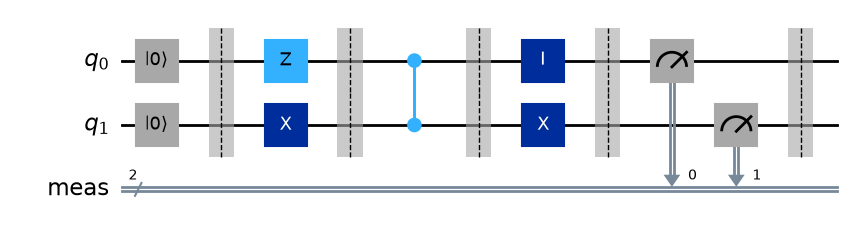

In [6]:
twirled_qc_list = pauli_twirl_cz(qc, num_circuits=3,seed=1)
for circuit in twirled_qc_list:
    display(circuit.draw("mpl"))

Pauli twirling requires a high number of randomizations in order to yield a valid approximation of an error channel $\Lambda$ with $\Lambda_P$, usually in the order of hundreds or more. Quantum Inspire places limits on how many circuits one can execute in a single job (currently the limit is set to 5). That is why it is useful to combine multiple randomizations into a single circuit of a single job, where the circuits get 'stitched' together back-to-back.

For the above list of twirled quantum circuits to be stiched up together into one quantum circuit, we just have to use it as an input to the function `stitch_circuits`,

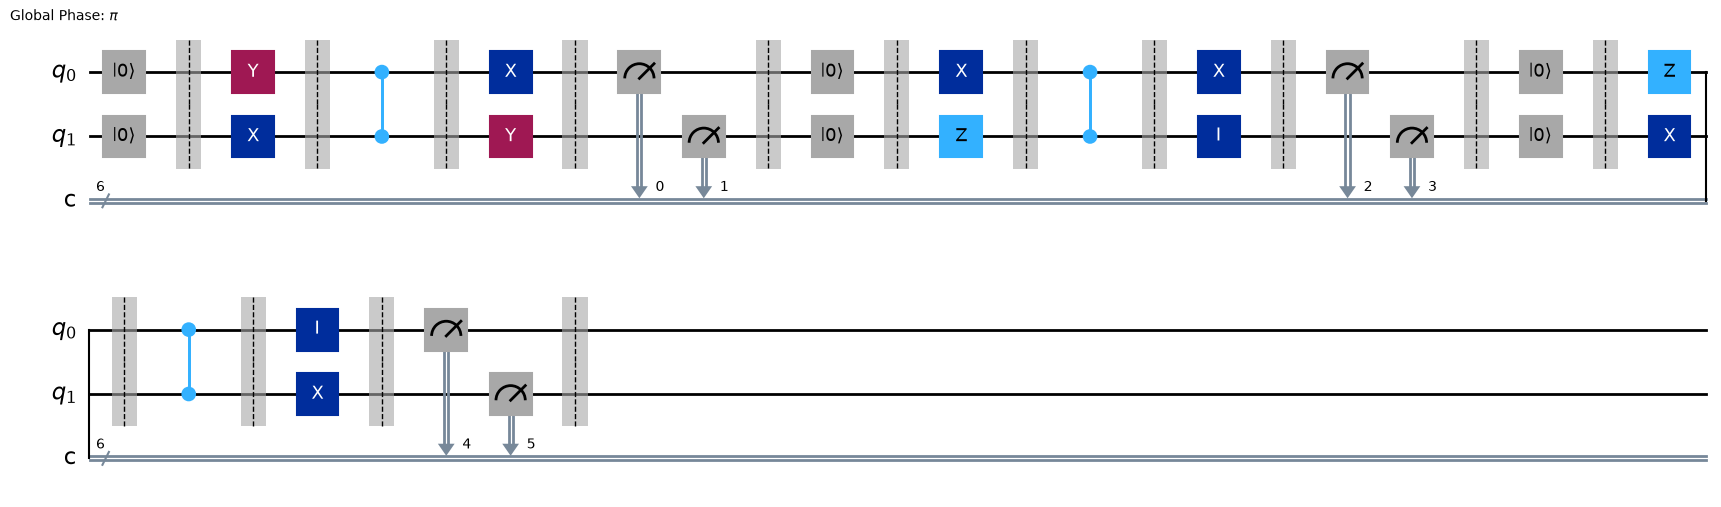

In [7]:
combined_qc = stitch_circuits(twirled_qc_list)
combined_qc.draw("mpl")

Combining multiple randomizations into a single quantum circuit is automatically handled in the noise learning/amplification classes as we will see later, and can be specified via the `num_stitched_circuits` parameter in the `.run()` function.

It is important to note that one cannot combine arbitrarily many circuits:
1.  The control hardware has a certain memory limit for the number of instructions in a single quantum circuit, therefore the number of randomizations that can be combined and stitched together depend on how large the final quantum circuit is. 
1. Quantum Inspire currently places a total execution time limit of 5 minutes for each job submitted.

When either of these two cases applies, an error will occur and no results will be obtained. 


# 4. Learning the approximated $\Lambda_P$ noise of a CZ gate

Once we have successfully twirled a general noise channel $\Lambda$ into $\Lambda_P$, we then need to learn it in order to be able to use it later on. But what does it mean 'learning' a noise channel? As we saw in the previous section, an n-qubit Pauli error channel $\Lambda_P$ has a simple structure and can be described as

$$

\Lambda_P (P_i) = f_i P_i,

$$

for $\Lambda_P$ acting on an n-qubit Pauli operator. By 'learning' here we mean estimating the Pauli fidelities $f_i$ for all $i$.

To gain a bit of an intuition on the fidelities, let us imagine a very simple scenario of two qubits both prepared in the $\ket{+} = \left( \ket{0} + \ket{1} \right) / \sqrt{2}$ state,

$$

\ket{++} = \frac{1}{2} \left( \ket{00} + \ket{01} + \ket{10} + \ket{11} \right).

$$

If we use the density matrix formalism to rewrite the above state,

$$

\rho = \ket{++}\bra{++} = \frac{1}{4}(II + IX + XI + XX),

$$

then the action of $\Lambda_P$ yields

$$

\Lambda_P ( \rho ) = \frac{1}{4}\left(II + f_{IX}IX + f_{XI}XI + f_{XX}XX\right),

$$

since $\Lambda_P$ is a linear operator and having already established that $\Lambda_P (P_i) = f_i P_i$. If we assume that the fidelities $f_i$ all take the value 1, the state $\rho$ is unaffected by the noise, since $\Lambda_P(\rho) = \rho$, while if the fidelities $f_i$ all take the value zero, the state $\rho$ becomes the maximally mixed state, $\Lambda_P(\rho) = II / 4$, meaning that all quantum information of the state has been destroyed.

The noise learning procedure in this module is based on learning a two-qubit gate noise channel as in [van den Berg, E., Minev, Z.K., Kandala, A. et al (2023)](https://doi.org/10.1038/s41567-023-02042-2). We make the assumption that for multiple CZ gates that are performed in parallel, the noise channel can be approximated as multiple two-qubit noise channels acting on each of the individual CZ gates, which assumes no or low CZ crosstalk.

<div style="text-align: center;">
  <img src="figures/2.0_figures/multiple_cz.jpg" width="700">
</div>

The Pauli fidelities are learned by executing circuits with variable even number of CZ gate repetitions (k), repeated for preparation and measurement in different Pauli bases. Learning the noise of a single CZ gate does however come with some added complexity; not all Paulis are invariant under the action of the CZ gate, allowing us to only measure Pauli fidelities in product pairs.

For example, if we prepare the qubits in the state $\ket{++}$, then $\rho = \ket{++}\bra{++} = \frac{1}{4}(II + IX + XI + XX)$. Let us now focus on the $IX$ term of the state $\rho$,

<div style="text-align: center;">
  <img src="figures/2.0_figures/origin_of_fidelity_pairs.jpg" width="700">
</div>

In the above illustrated example, the first application of $\Lambda_P$ only adds the multiplicative $f_{IX}$ term. The action of the CZ gate then transforms the term $IX$ into $ZX$. The second application of $\Lambda_P$ adds a $f_{ZX}$ term instead, resulting in the fidelity pair $f_{IX}f_{ZX}$. For some terms we can apply single qubit rotations to measure single Pauli fidelities instead, for example the $XX$ termb where the CZ gate transforms this into $YY$, but with single qubit rotations after the CZ gate we can turn $YY$ back into $XX$ before the application of the next $\Lambda_P$, resulting in $f_{XX}^2$ instead.

The fidelity pairs are extracted from exponential decays fit to the obtained expectation values,
$$
\langle P \rangle (k) = a \cdot (f_1f_2)^{k/2} + b,
$$

where $\langle P \rangle (k)$ is the measured Pauli expectation value as a function of the number of CZ repetitions $k$, $f_1f_2$ is the fidelity pair, and $a$, $b$ are fitting parameters.

<div style="text-align: center;">
  <img src="figures/2.0_figures/exp_decays.png" width="800">
</div>

To resolve the issue with the occuring fidelity pairs when trying to measure single fidelity terms, we use the symmetry condition assumption used by [van den Berg, E., Minev, Z.K., Kandala, A. et al (2023)](https://doi.org/10.1038/s41567-023-02042-2): the two fidelities that appear as a pair are treated as equal. We apply this assumption on the naturally occuring fidelity pairs that we can not correct with single qubit rotations; $f_{IX}f_{ZX}$, $f_{XI}f_{XZ}$, $f_{IY}f_{ZY}$, and $f_{YI}f_{YZ}$. We can continue with extracting the noise model error rates, commonly referred to as the Pauli error rates $\lambda_i$, by adding the fidelity estimates obtained from this assumption to the fidelity pairs we have measured.

For our noise model, we include all two-qubit Pauli operators $P \in \{\mathbb{I}, X, Y, Z\}^{\otimes 2}$. To aid with the extraction of the Pauli error rates, we define a matrix $M$ as follows,
$$
M_{a,b} =
\begin{cases}
0, & \text{if } [P_a,P_b] = 0,\\
1, & \text{if } [P_a,P_b] \neq 0.
\end{cases}
$$



We can then finaly extract the Pauli error rates $\lambda_i$ by solving the following equation,

$$
\vec{\lambda} = \mathop{\text{argmin}}_{\lambda \geq 0}||(M_1 + M_2)\vec{\lambda}+\log (\vec{f_1} * \vec{f_2})/2t||^2.
$$

Here $t = 60$ ns is the duration of the CZ gates of the superconducting backends of Quantum Inspire and $\vec{f_1} * \vec{f_2}$ is an element-wise product and represents the fidelity pairs. The vectors $\vec{f_1}$ and $\vec{f_2}$ contain respectively the first and second Pauli of each fidelity pair, the rows of matrices $M_1$ and $M_2$ correspond to these various Paulis, while their columns correspond to the Paulis included in the noise model.

The `CZPauliFidelityMeasurements` class performs all measurements for obtaining the Pauli fidelities and automatically runs the analysis for extracting the noise model parameters.
Once executed, an experiment folder will be automatically created, and all processed results are saved in the `project_data_{timestamp}.json` file. By default, the folder is created in `Path.home() / "Documents" / "QuantumInspireProjects"`, but this can be altered in `CZPauliFidelityMeasurements.BASE_DIR` or in the instance itself.

In [8]:
noise_learning = CZPauliFidelityMeasurements(backend,
                                            qubit_pairs=[[0, 2]],
                                            )
pauli_error_rates = noise_learning.run(num_shots = 256)

Creating project directory
Creating circuits
Executing circuits


           Basis:  100%|██████████| 7/7 [01:32<00:00, 13.22s/it]


In [9]:
print(pauli_error_rates) # in units of [1/s]

{'Qubit pair [0, 2]': {'XI': np.float64(39525.154529571075), 'YI': np.float64(46560.91340283399), 'ZI': np.float64(59542.17315163795), 'IX': np.float64(39608.257113929234), 'IY': np.float64(34778.675880290924), 'IZ': np.float64(33423.885742181694), 'XX': np.float64(31721.736700987105), 'XY': np.float64(40355.28393350291), 'XZ': np.float64(39385.040317458726), 'YX': np.float64(34722.43869945369), 'YY': np.float64(31711.22538101017), 'YZ': np.float64(46707.30601176024), 'ZX': np.float64(36319.63039265424), 'ZY': np.float64(38015.31966026956), 'ZZ': np.float64(82480.77427751971)}}


The noise learning can also be performed for multiple qubit pairs at the same time as long they do not include the same qubit in multiple pairs,

In [ ]:
noise_learning = CZPauliFidelityMeasurements(
    backend,
    qubit_pairs=[[0,2], [1,3], [4,6]],
)
noise_learning.run(256)

Previously obtained noise parameters can also be loaded from disk. This is done by specifying the backend name and the oldest date to inlcude in the search for saved results. The function attempts to load the most recent noise parameters for each qubit pair that it can find. Optionally one can specify an end date, and start / end times, to load noise parameters from a specific experiment (or manually copy them from the json),

In [11]:
pauli_error_rates = load_error_rates_from_disk(backend.name, start_date="20260827")

# 5. Noise amplification and Zero-noise extrapolation

The noise amplification follows the probabilistic error amplification (PEA) procedure shown by [Kim, Y., Eddins, A., Anand, S. et al (2023)](https://doi.org/10.1038/s41586-023-06096-3).

It turns out (see supplemental information of [van den Berg, E., Minev, Z.K., Kandala, A. et al (2023)](https://doi.org/10.1038/s41567-023-02042-2)) that the twirled noise channel $\Lambda_P$ is described mathematically as a composition of individual simpler error channels $\Lambda_k$,

$$
\Lambda_P(\rho) = \bigcirc_k \left(\Lambda_k(\cdot)\right)\rho,
$$

where $\Lambda_k(\rho) = (1-p_k)\rho + p_kP_k \rho P_k$ with $P_k$ being n-qubit Pauli operators drawn with a probability $p_k$ from the set $\{I, X, Y, Z \}^n$. Here $\cdot$ stands as the place holder $\Lambda_k(\cdot)\rho = \Lambda_k(\rho)$. The probabilities $p_k$ relate to the learned Pauli error rates as

$$
p_k = (1 - e^{-2t\alpha \lambda_k})/2,
$$

with $t = 60$ ns the duration of the CZ gate and $\alpha$ a non-negative scaling parameter. In practice, in order to apply the noise channel $\Lambda_P$ we have to perform a coin toss with probability $p_k$ in order to apply (or not) each individual error channel $\Lambda_k$,

<div style="text-align: center;">
  <img src="figures/2.0_figures/noise_model.jpeg" width="900">
</div>

Averaging over different randomizations adds an additional Pauli channel, scaled by $\alpha$, in front of the CZ gate, to give an effective noise gain of $G=\alpha + 1$.

<div style="text-align: center;">
  <img src="figures/2.0_figures/PEA.jpg" width="900">
</div>

<div style="text-align: center;">
  <img src="figures/2.0_figures/effective_noise_gain.jpg" width="900">
</div>

By varying $\alpha$ we are able to control the effective noise gain level $G$. Once we have executed a circuit at multiple different noise gains, we can make use of ZNE to obtain the noise-mitigated estimate of the expectation value. To do that, we perform a fit (linear or exponential) on the measured expectation values $E(G)$, then extrapolate to $G=0$ to obtain the noise-mitigated estimate $E^{\text{ZNE}}$.

<div style="text-align: center;">
  <img src="figures/2.0_figures/ZNE.png" width="700">
</div>

## 5.1 Define a test circuit for ZNE

Let us first define a quantum circuit on which we want to apply ZNE, with a total of 10 CZ gates. At the end of it, we want to measure the expectation value $\langle ZZ \rangle$ for multiple noise gain levels, and apply ZNE to estimate the error-mitigated value $\langle ZZ \rangle(G=0)$.

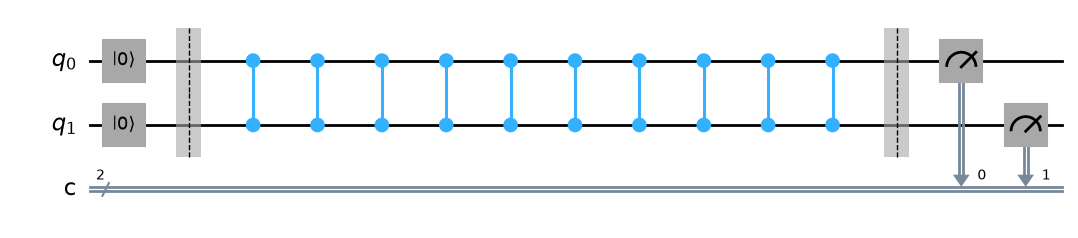

In [12]:
qc = QuantumCircuit(2,2)
qc.reset([0,1])
qc.barrier()
for dummy_idx in range(10):
    qc.cz(0,1)
qc.barrier()
qc.measure(0,0)
qc.measure(1,1)
qc.draw("mpl")

Before we can apply noise amplification to the circuit, we first need to transpile it

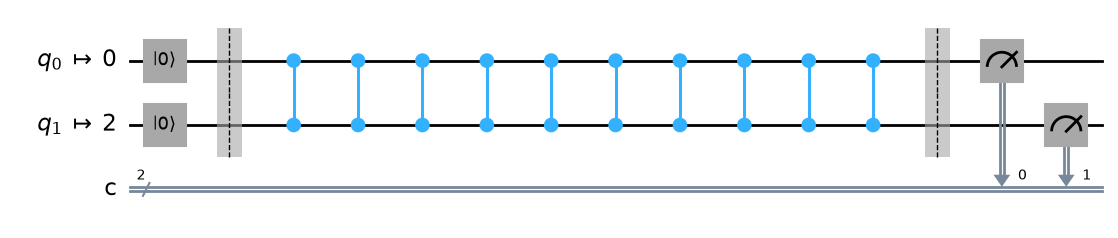

In [13]:
# the QI Tuna systems have the rz gate as an additional native gate, but the Starmon-7 simulator does not.
native_gates = ["id", "s", "sdg", "t", "tdg", "x", "rx", "y", "ry", "z", "cz", "delay", "reset", "measure"]
qc_transpiled = transpile(qc,
                          backend,
                          basis_gates=native_gates,
                          initial_layout=[0,2],
                          optimization_level=0) # we set the optimization level to 0, 
                                                # as otherwise it would remove al CZ gates
qc_transpiled.draw('mpl')

For each CZ gate in the circuit we need to get the Pauli error rates in order to perform noise amplification. 
Using the cell below we can extract all qubit pairs used in the circuit

In [14]:
qubit_pairs = get_qubit_pairs(qc_transpiled)
print(qubit_pairs)

[[0, 2]]


The Pauli error rates should be learned for all qubit pairs in the circuit before proceeding (see Sec. 4). Alternatively, the parameters below can be used for continuing this demo

In [15]:
pauli_error_rates = { # in units of [1/s]
    "Qubit pair [0, 2]": {
            "XI": 42565.098340440454,
            "YI": 46226.78002823898,
            "ZI": 57864.11967535045,
            "IX": 38158.6807055183,
            "IY": 38478.02242420593,
            "IZ": 33256.417603906906,
            "XX": 36009.104138000905,
            "XY": 32708.597059315314,
            "XZ": 41947.047831649914,
            "YX": 33286.00519068634,
            "YY": 34848.95661473187,
            "YZ": 46796.94620486484,
            "ZX": 38459.99192199387,
            "ZY": 38197.38489242815,
            "ZZ": 78883.10049226432
         }
}

## 5.2 Apply probabilistic error amplification (PEA)

Now we can finally apply PEA; please make sure that the order of the qubits in `qubit_list` matches the order of the classical bits used to measure them,


In [16]:
exp = NoiseAmplification(backend=backend,
                         transpiled_circuit=qc_transpiled,
                         qubit_list=[0,2],
                         )
raw_probabilities, ro_corrected_probabilities = exp.run(
    pauli_error_rates=pauli_error_rates,
    noise_levels=[1.0, 1.2, 1.6, 2.3],
)
print(ro_corrected_probabilities)

Creating project directory
Creating circuits
Executing circuits


    Noise Levels:  100%|██████████| 4/4 [01:38<00:00, 24.52s/it]

{'G=1.0': [{'00': np.float64(0.7684837846283952), '01': np.float64(0.07561303898406589), '10': np.float64(0.08697070523563304), '11': np.float64(0.06893247114875302)}], 'G=1.2': [{'00': np.float64(0.7276908448061573), '01': np.float64(0.0884812295004046), '10': np.float64(0.10075072823705003), '11': np.float64(0.08307719745013067)}], 'G=1.6': [{'00': np.float64(0.6637028456683529), '01': np.float64(0.10849336129618121), '10': np.float64(0.12603081072966552), '11': np.float64(0.10177298230785106)}], 'G=2.3': [{'00': np.float64(0.5529751362617954), '01': np.float64(0.15321996879190058), '10': np.float64(0.15686235943504248), '11': np.float64(0.13694253550425603)}]}


Once we have obtained the measurement probabilities of multiple noise levels, we can apply ZNE. We can select a linear ("lin"), exponential ("exp"), or automatic ("auto") fit, when selecting automatic, both a linear and an exponential fit are performed and the fit with the lowest sum of squared residuals is chosen.
The example below shows how one can use ZNE when manually computing the expectation values,

In [17]:
observable = "ZZ"
expectation_values = {
    noise_level: observable_expectation_values_Z_basis(probabilities, observable)[0]
    for noise_level, probabilities in ro_corrected_probabilities.items()      
}

extrapolated, fit_results = perform_ZNE(
    expectation_values=expectation_values,
    method="auto"
)

print(extrapolated)

0.8947672371723919


It is however recommended to use ZNE via the analysis class. This ensures that the results get saved to the same JSON file that contains the noise amplification data,

In [18]:
zne = ZNE(exp.project_dir)
mitigated_expectation_values = zne.run(observables=[["ZZ","IZ","ZI"]], method="auto")
print(mitigated_expectation_values)

[{'ZZ': np.float64(0.8962378201359248), 'IZ': np.float64(0.9285463701532654), 'ZI': np.float64(1.0164779245196571)}]


Figures of the extrapolation have been automatically created and saved in:

In [19]:
zne.project_dir

PosixPath('/Users/mariossamiotis/Documents/QuantumInspireProjects/20260827/125438_circuit-1306_noise_amplification_G=[1.0, 1.2, 1.6, 2.3]')

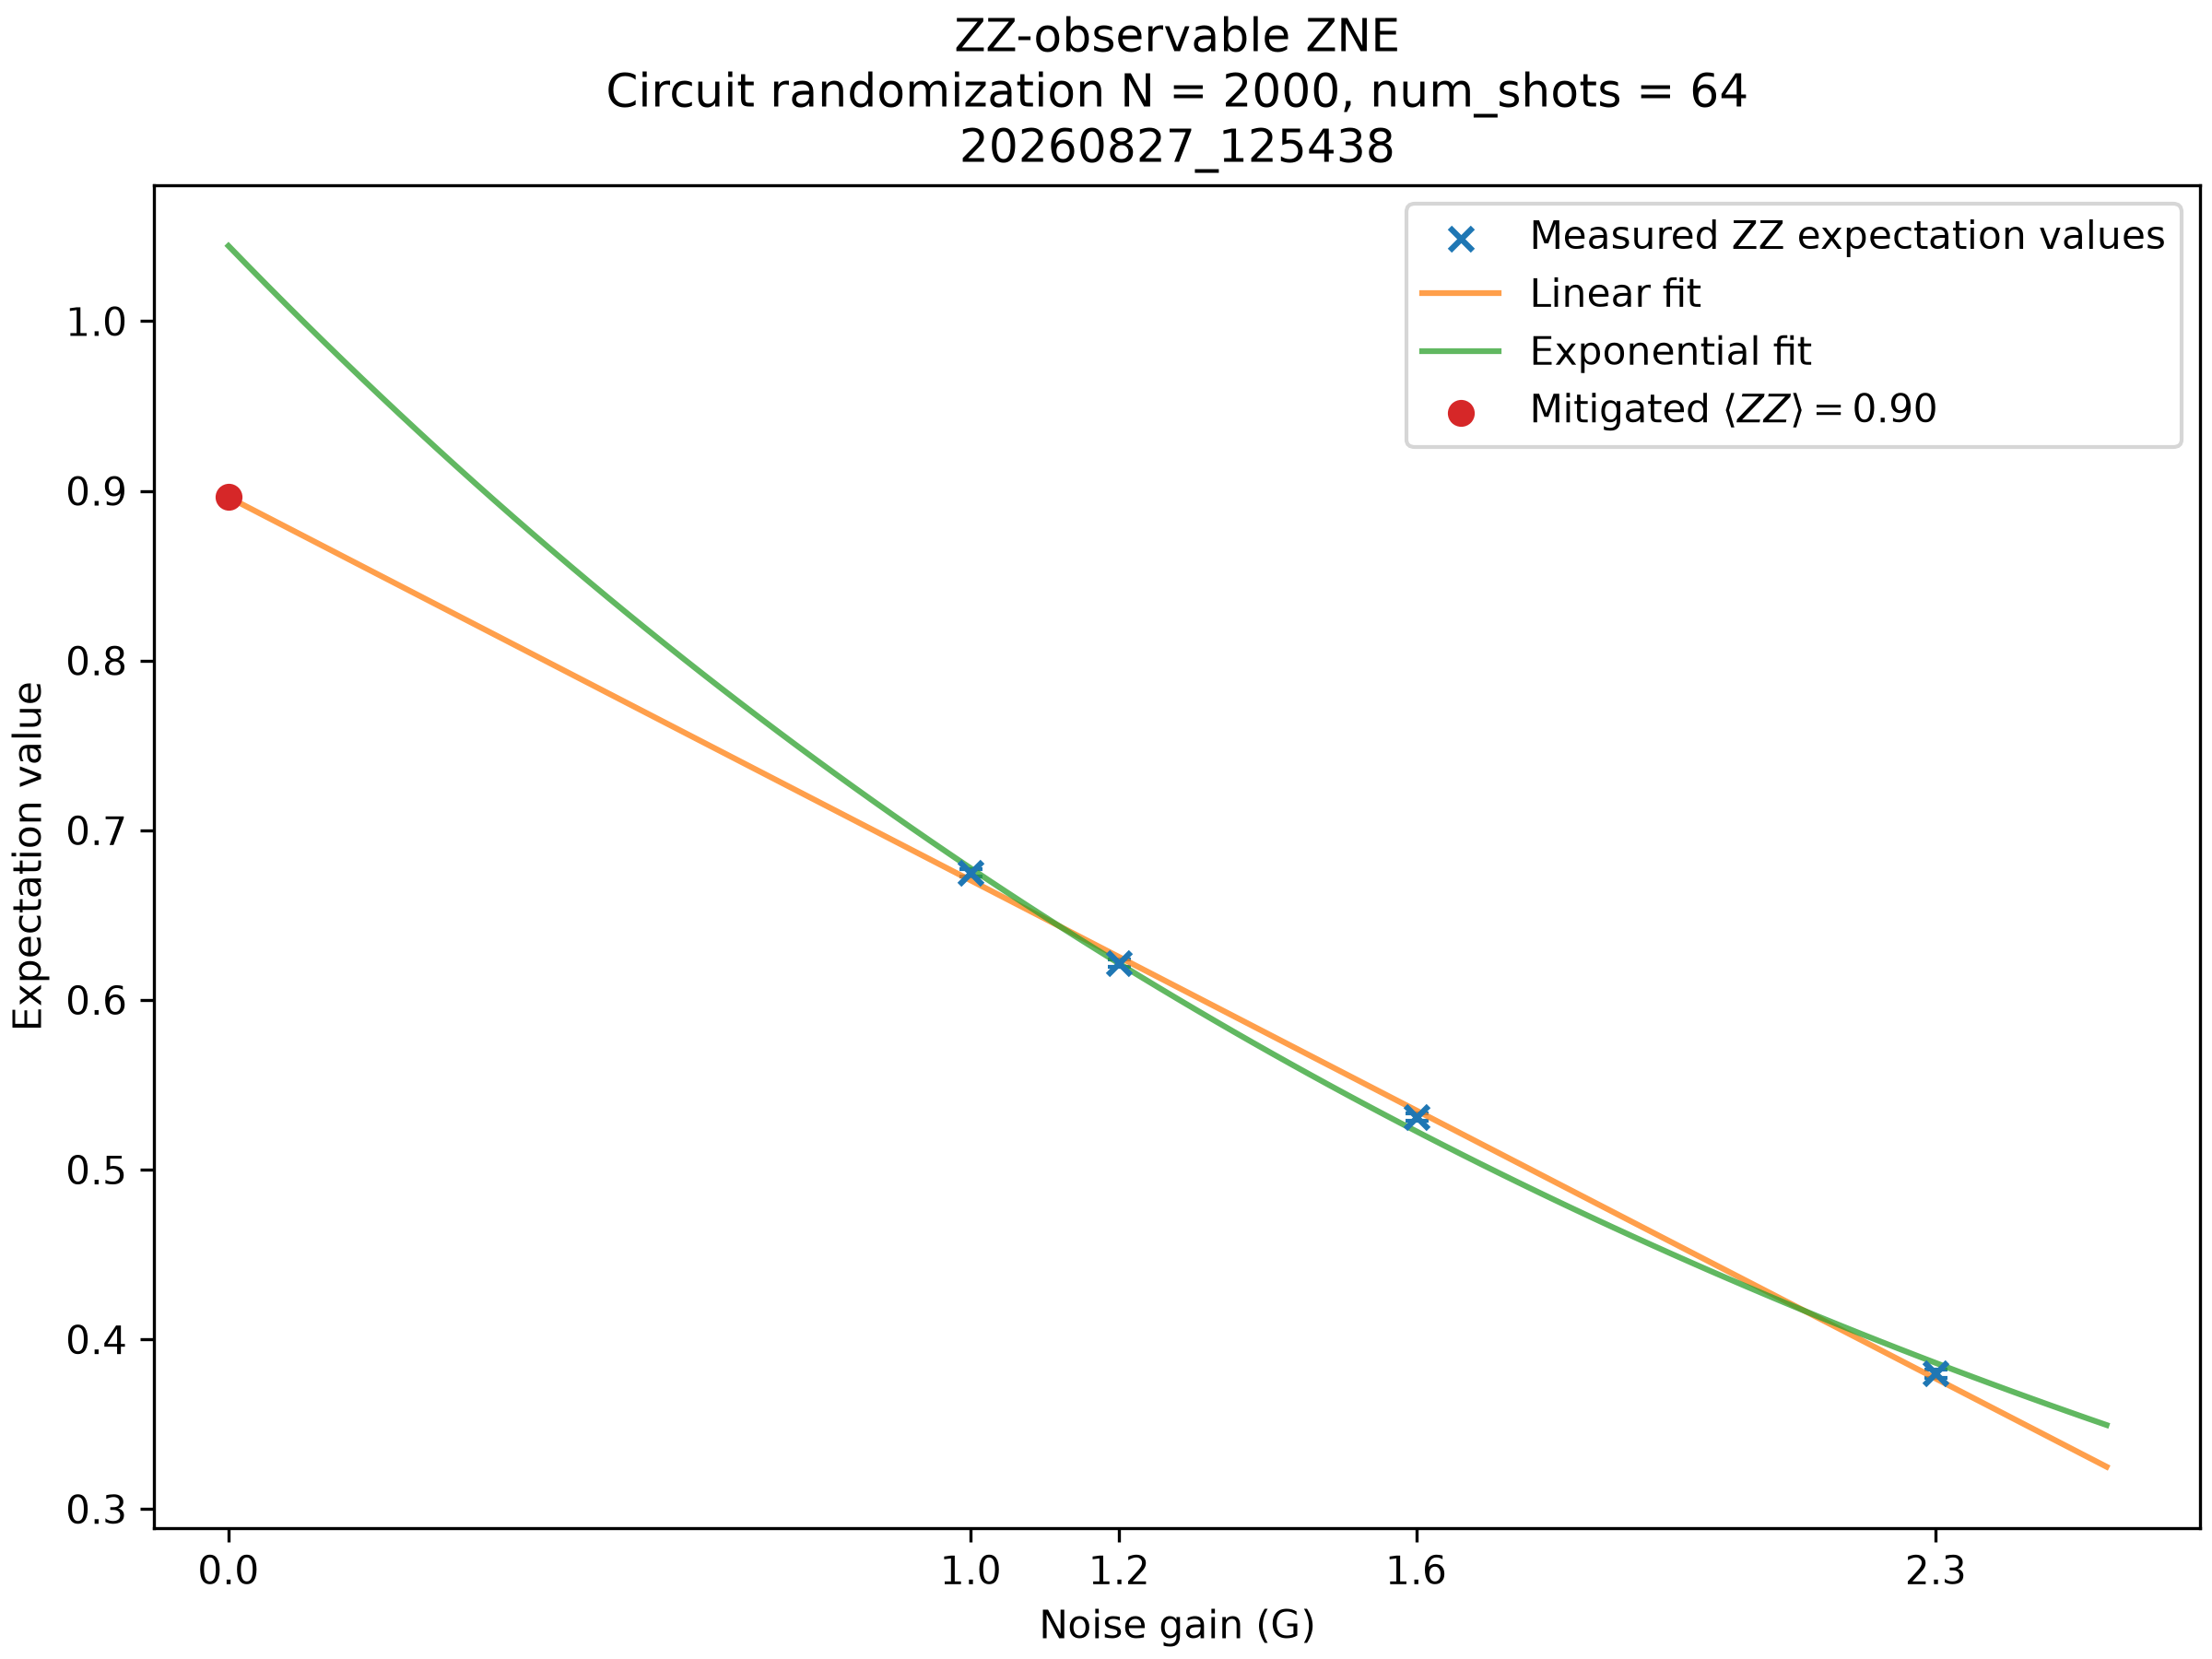

In [20]:
from IPython.display import Image

display(Image(zne.project_dir / "ZNE_figures" / f"ZZ-observable_ZNE_{zne.timestamp}.png", width=1200))

## 5.3 Using mid-circuit measurements with ZNE

All previously shown tools can also be used in combination with mid-circuit measurements, under the assumptions that:
1. All measurement blocks apply on the same qubits
1. The measurements within a block appear in the same order as in all other blocks
1. The first measurement block uses the first classical bits, eg. if you have 2 qubits; the first measurement block uses classical bits 0 and 1, the second 2 and 3, etc.

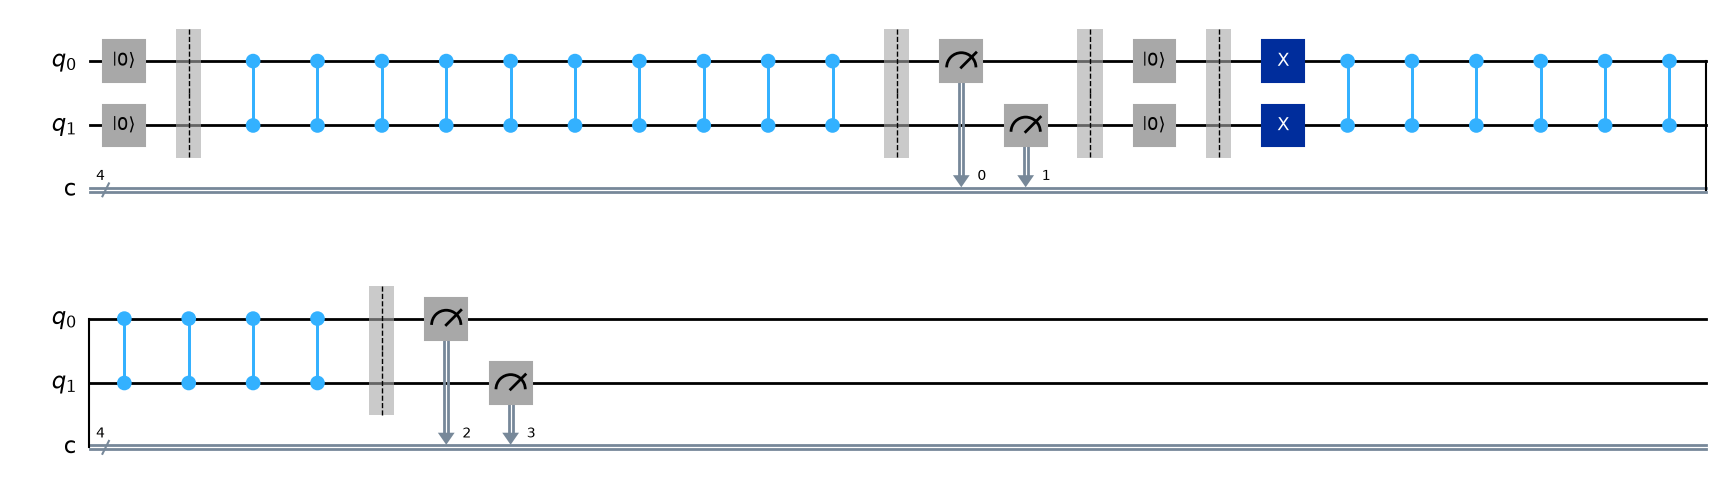

In [21]:
qc = QuantumCircuit(2,4)
qc.reset([0,1])
qc.barrier()
for dummy_idx in range(10):
    qc.cz(0,1)
qc.barrier()
qc.measure(0,0)
qc.measure(1,1)
qc.barrier()
qc.reset([0,1])
qc.barrier()
qc.x([0,1])
for dummy_idx in range(10):
    qc.cz(0,1)
qc.barrier()
qc.measure(0,2)
qc.measure(1,3)
qc.draw("mpl")

In [22]:
# the QI Tuna systems have the rz gate as an additional native gate, but the Starmon-7 simulator does not.
native_gates = ["id", "s", "sdg", "t", "tdg", "x", "rx", "y", "ry", "z", "cz", "delay", "reset", "measure"]
qc_transpiled = transpile(qc,
                          backend,
                          basis_gates=native_gates,
                          initial_layout=[0,2],
                          optimization_level=0) # we set the optimization level to 0,
                                                # as otherwise it would remove al CZ gates

We can run the noise amplification in exactly the same way, but notice that the resulting probabilities now contain two dictionaries

In [23]:
exp = NoiseAmplification(backend=backend,
                         transpiled_circuit=qc_transpiled,
                         qubit_list=[0,2],
                         )
raw_probabilities, ro_corrected_probabilities = exp.run(
    pauli_error_rates=pauli_error_rates,
    noise_levels=[1.0, 1.2, 1.6, 2.3],
)

ro_corrected_probabilities

Creating project directory
Creating circuits
Executing circuits


    Noise Levels:  100%|██████████| 4/4 [02:19<00:00, 34.95s/it]


{'G=1.0': [{'00': np.float64(0.766056823603042),
   '01': np.float64(0.07673134638895704),
   '10': np.float64(0.08702344780965013),
   '11': np.float64(0.07018838219482128)},
  {'00': np.float64(0.06887649712382722),
   '01': np.float64(0.08590256668107442),
   '10': np.float64(0.07685913407139676),
   '11': np.float64(0.768361802121808)}],
 'G=1.2': [{'00': np.float64(0.7352713561759735),
   '01': np.float64(0.0866432017490054),
   '10': np.float64(0.09840013522079477),
   '11': np.float64(0.07968530685347229)},
  {'00': np.float64(0.08248677687663263),
   '01': np.float64(0.09729585946591465),
   '10': np.float64(0.08831196603646578),
   '11': np.float64(0.7319053976206115)}],
 'G=1.6': [{'00': np.float64(0.6694053374937682),
   '01': np.float64(0.11153209558363852),
   '10': np.float64(0.11525881276556899),
   '11': np.float64(0.10380375415324078)},
  {'00': np.float64(0.10311645072045585),
   '01': np.float64(0.12824589741530043),
   '10': np.float64(0.10530569442593632),
   '11':

Similarly we can apply ZNE, for this example we use the "ZZ" and "IZ" expectation values of the first measurement block, and the "ZI" and "ZZ" expectation values of the second block

In [24]:
zne = ZNE(exp.project_dir)
mitigated_expectation_values = zne.run(observables=[["ZZ","IZ"], ["ZI","ZZ"]], method="auto")
print(mitigated_expectation_values)

[{'ZZ': np.float64(0.8865533871835855), 'IZ': np.float64(0.9369081031221328)}, {'ZI': np.float64(-0.9898799688022849), 'ZZ': np.float64(1.0110309658640262)}]


Below we print the extrapolation plots for both measurement blocks,

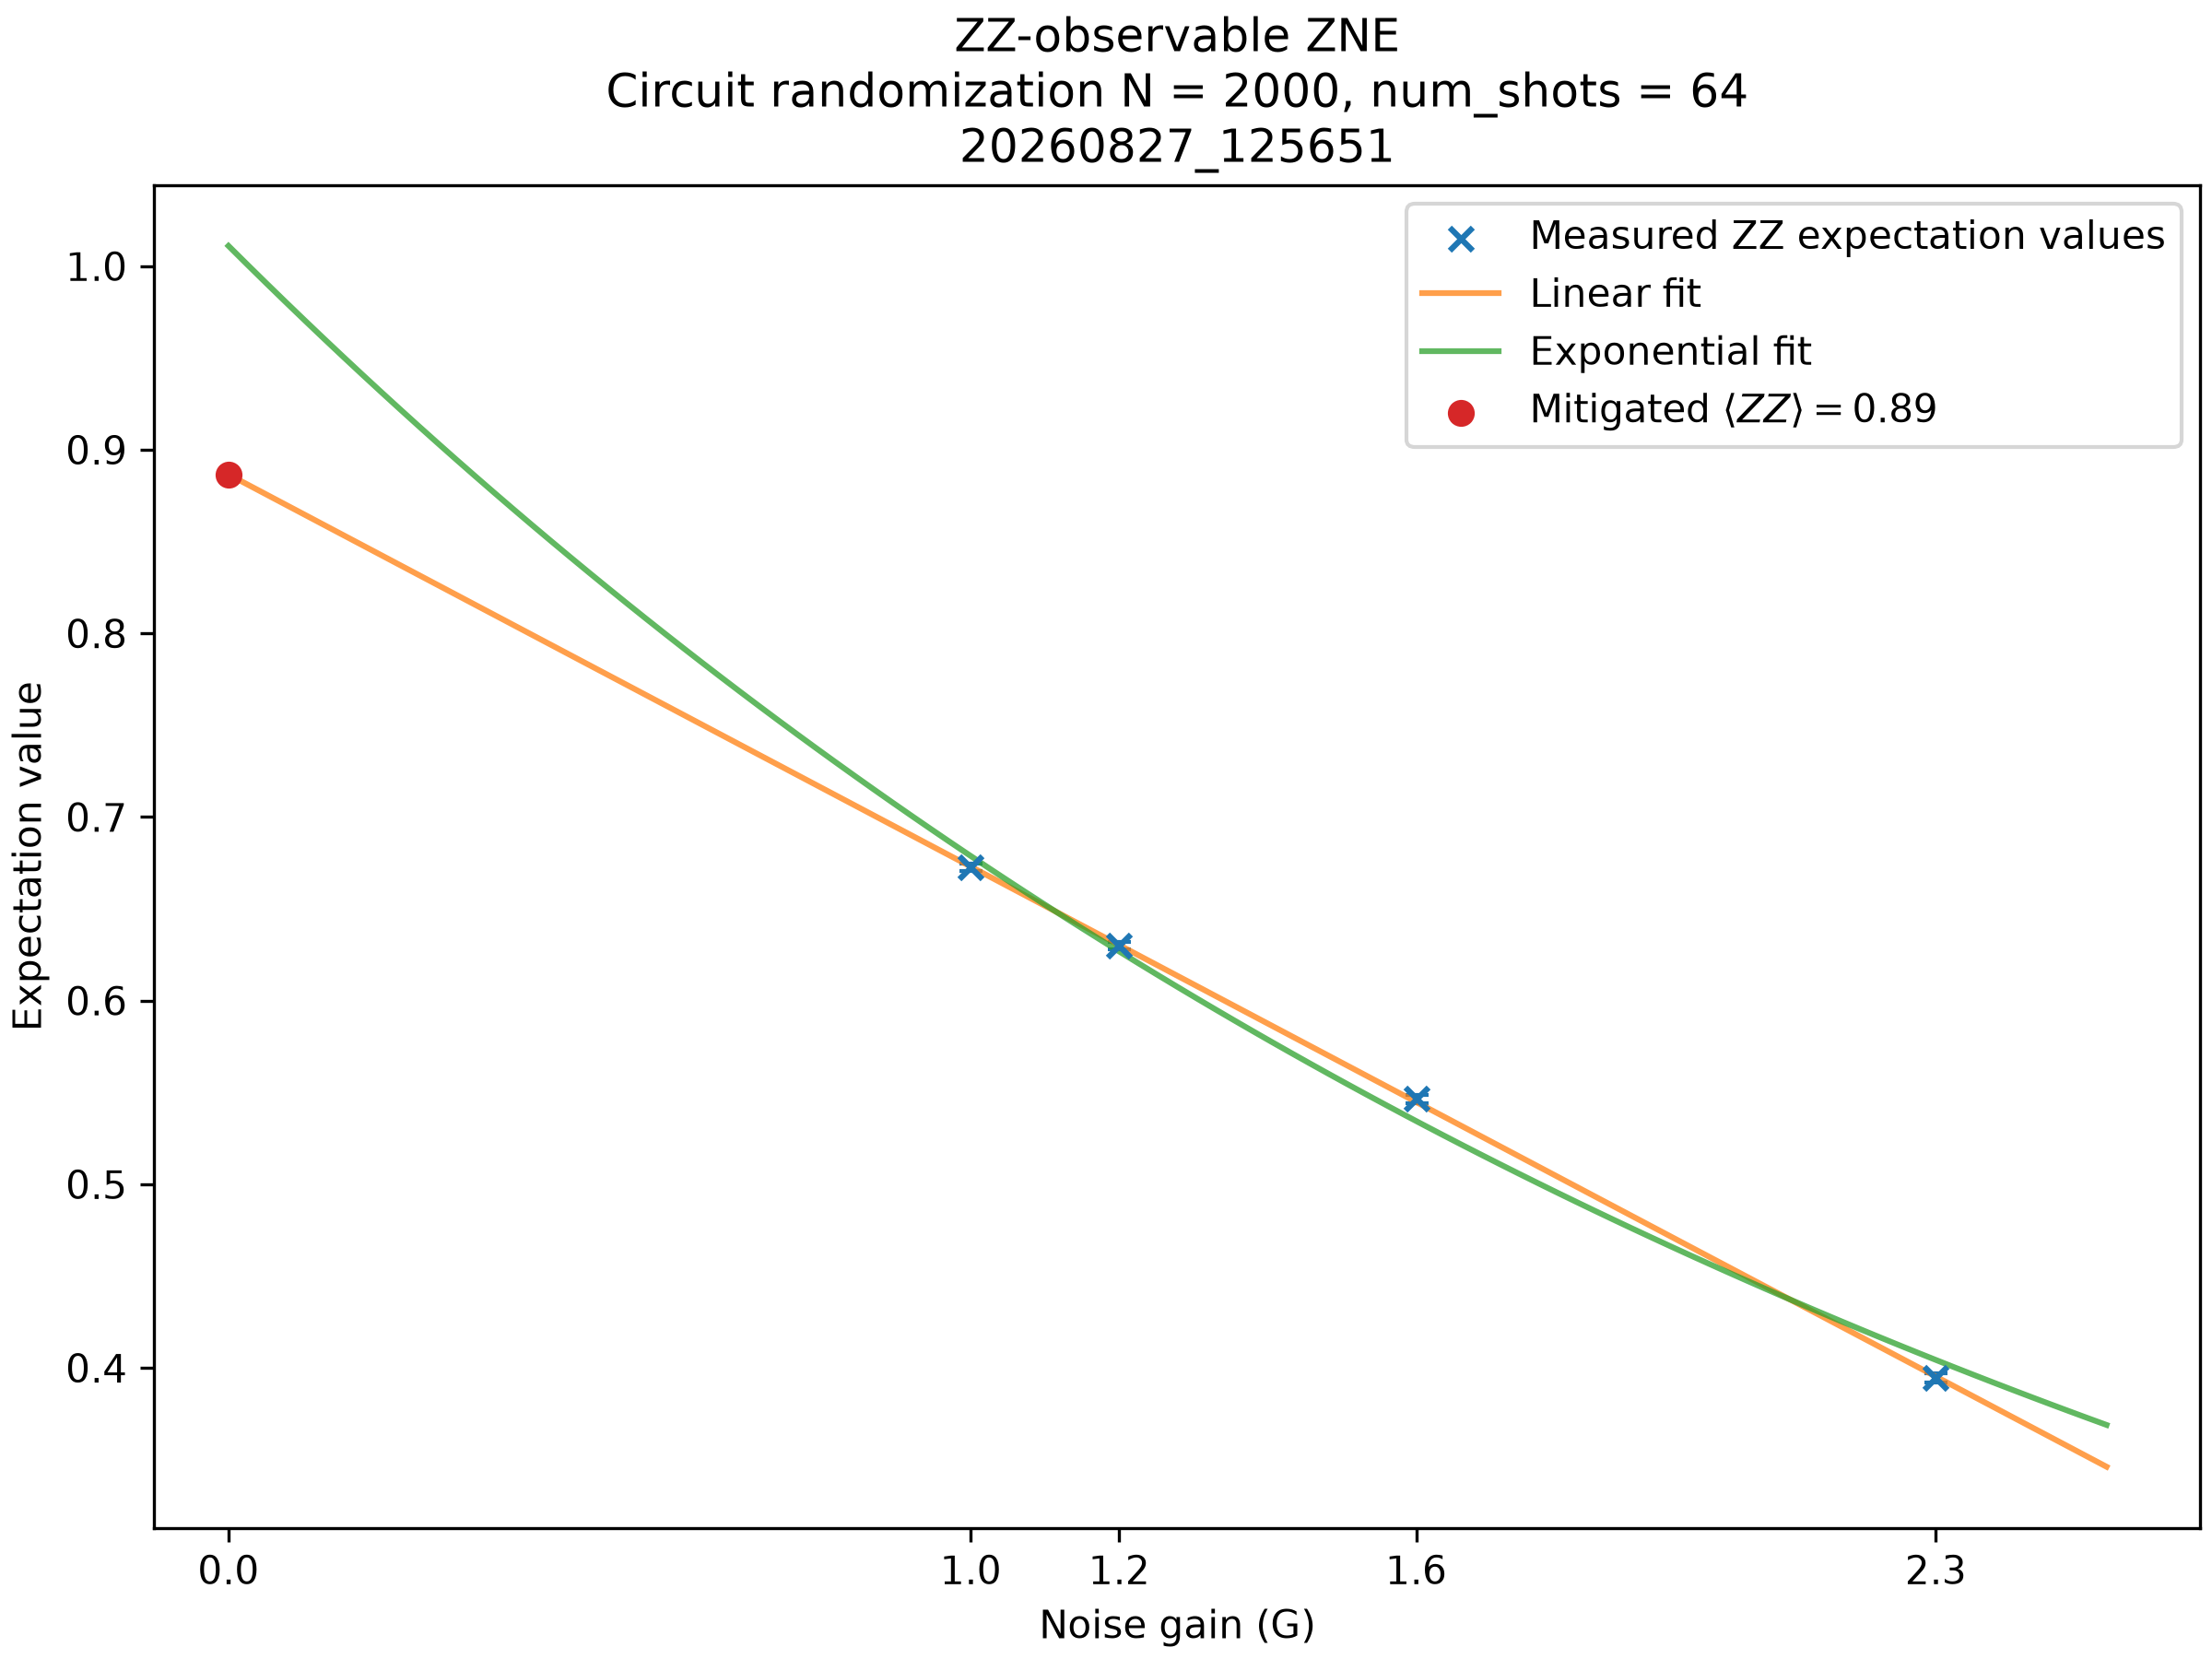

In [25]:
display(Image(zne.project_dir / "ZNE_figures" / "measurement_block_0" / f"ZZ-observable_ZNE_{zne.timestamp}.png", width=1200))

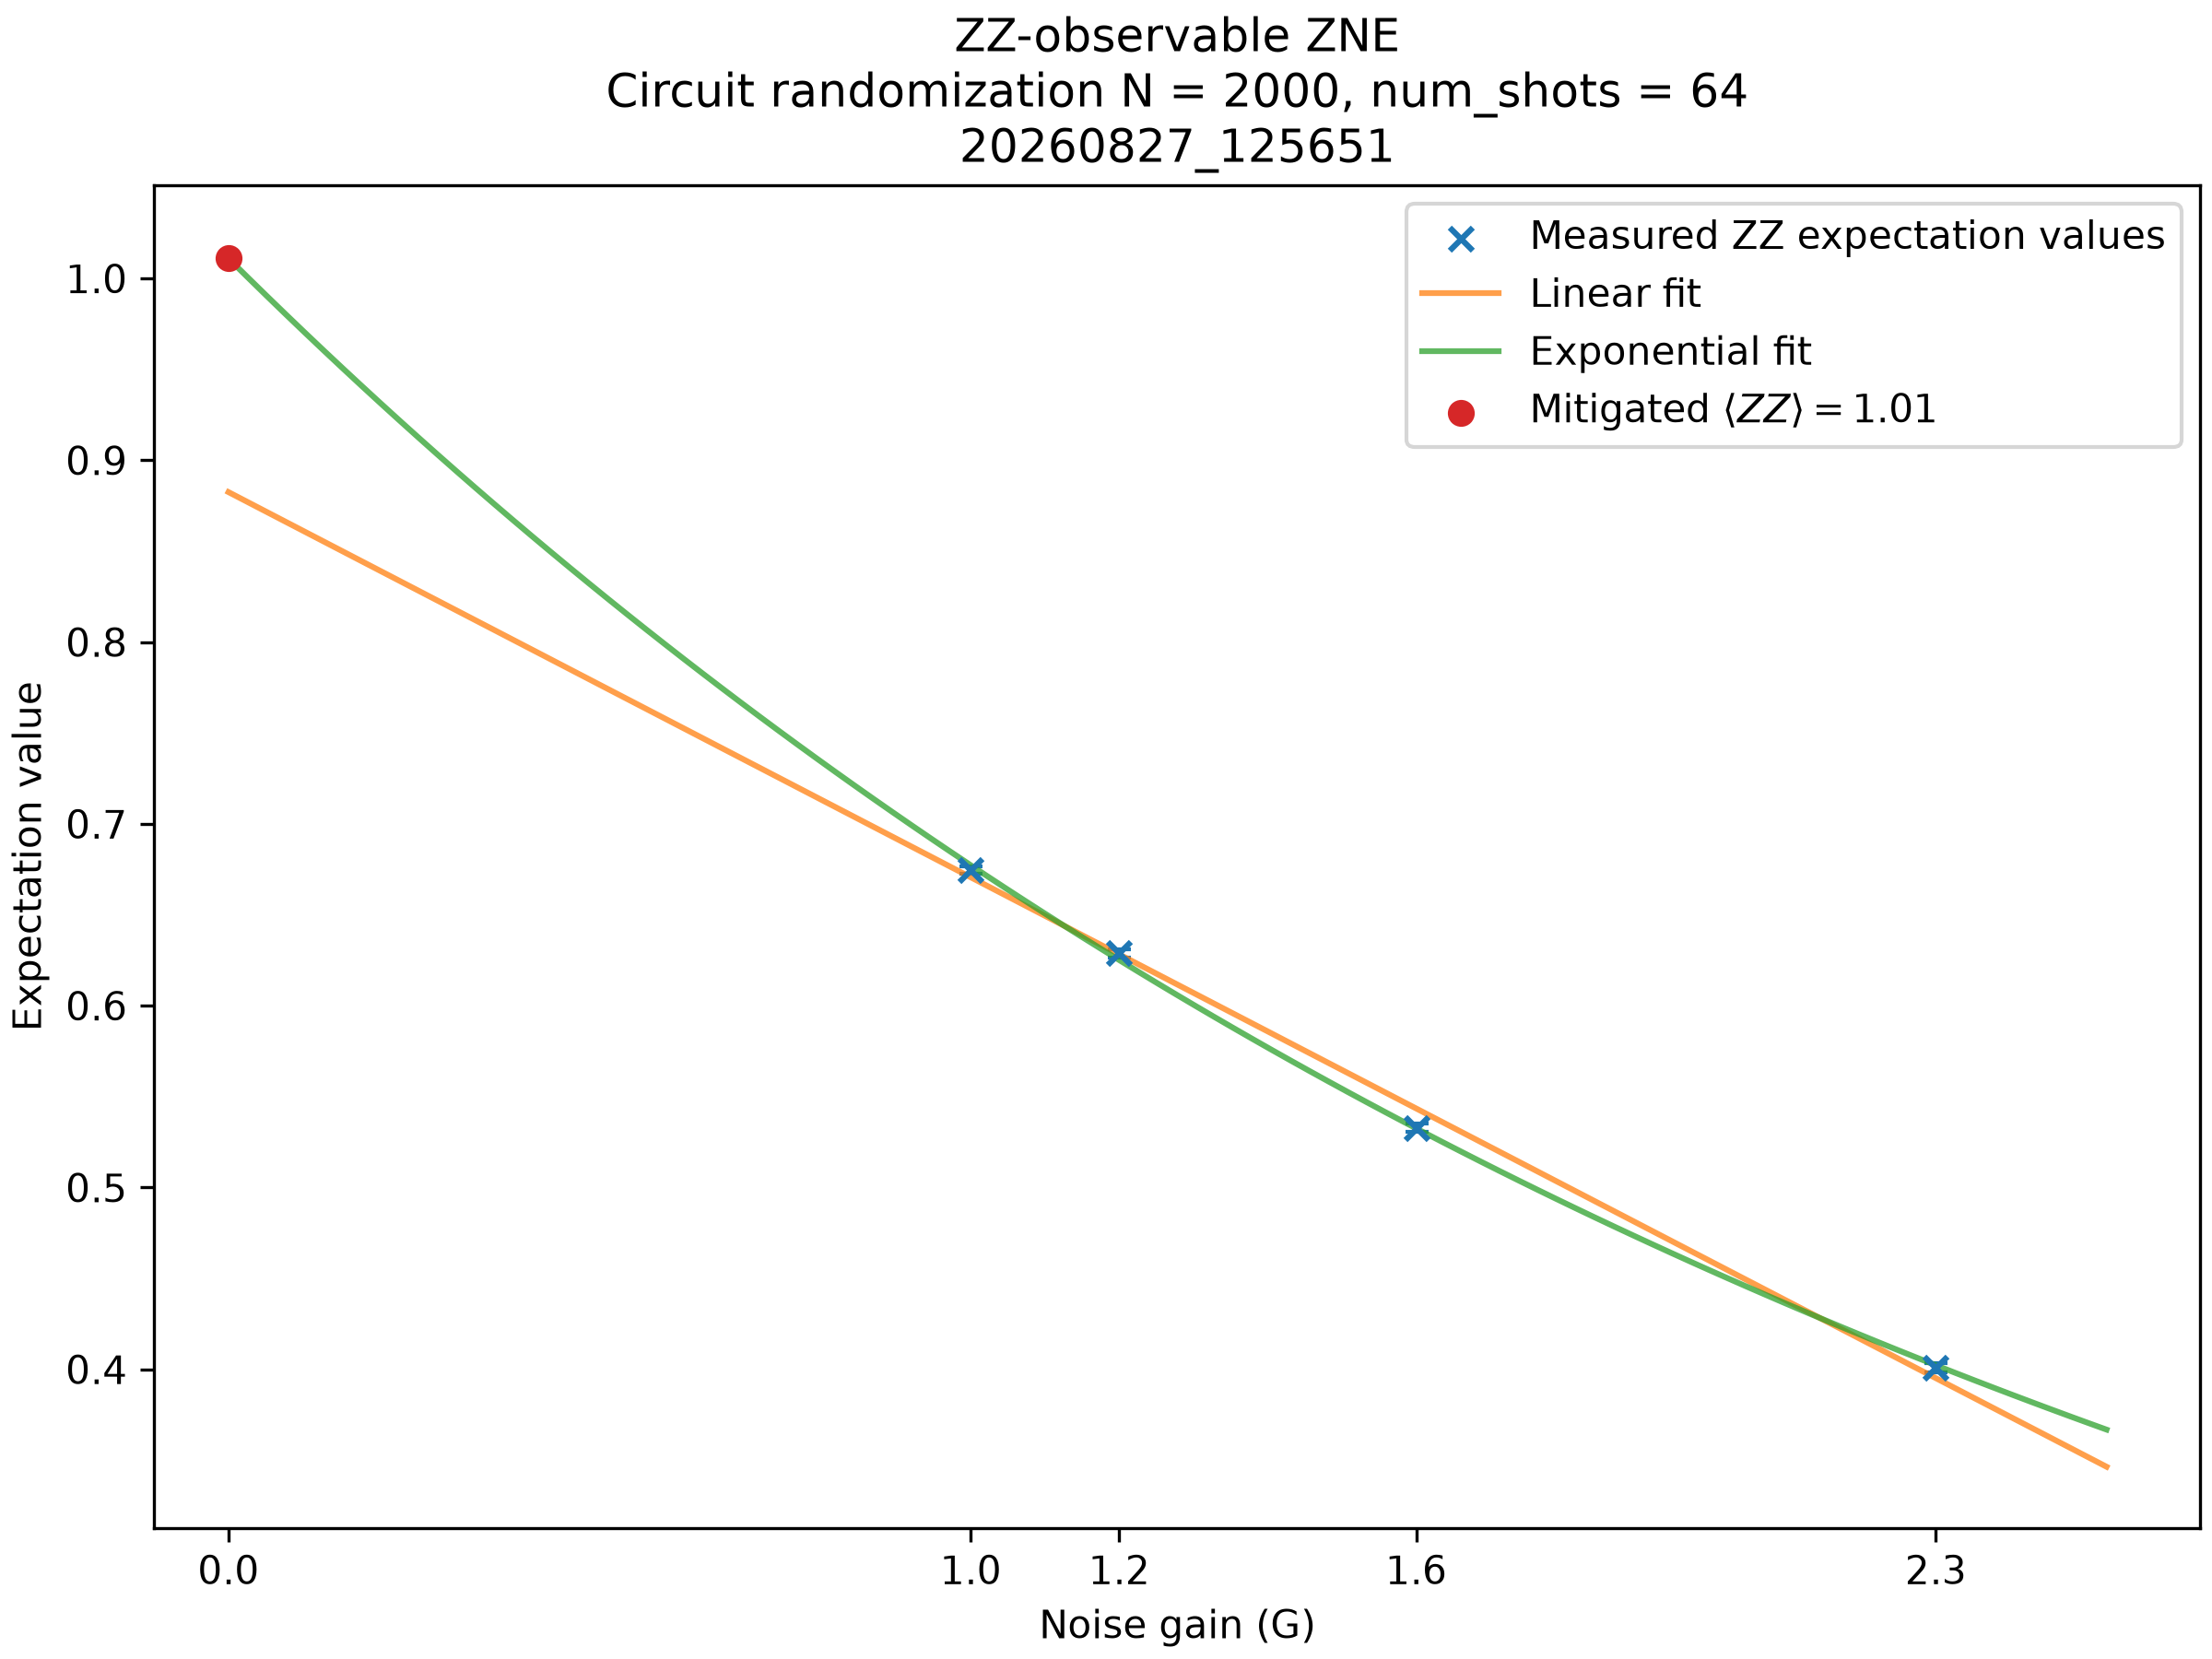

In [26]:
display(Image(zne.project_dir / "ZNE_figures" / "measurement_block_1" / f"ZZ-observable_ZNE_{zne.timestamp}.png", width=1200))

## 5.4 Applying the technique to quantum circuits with more than two qubits

These techniques can also be applied to circuits containing more than two qubits. This module assumes that when CZ gates are performed in parallel, that the noise channel can be described as seperate two-qubit noise channels (assumes CZ crosstalk is low to none). This is different from the work of [van den Berg, E., Minev, Z.K., Kandala, A. et al (2023)](https://doi.org/10.1038/s41567-023-02042-2), where they include Pauli operators in the noise model that act on two neighbouring qubits that are not performing a CZ gate together, but instead with other qubits.

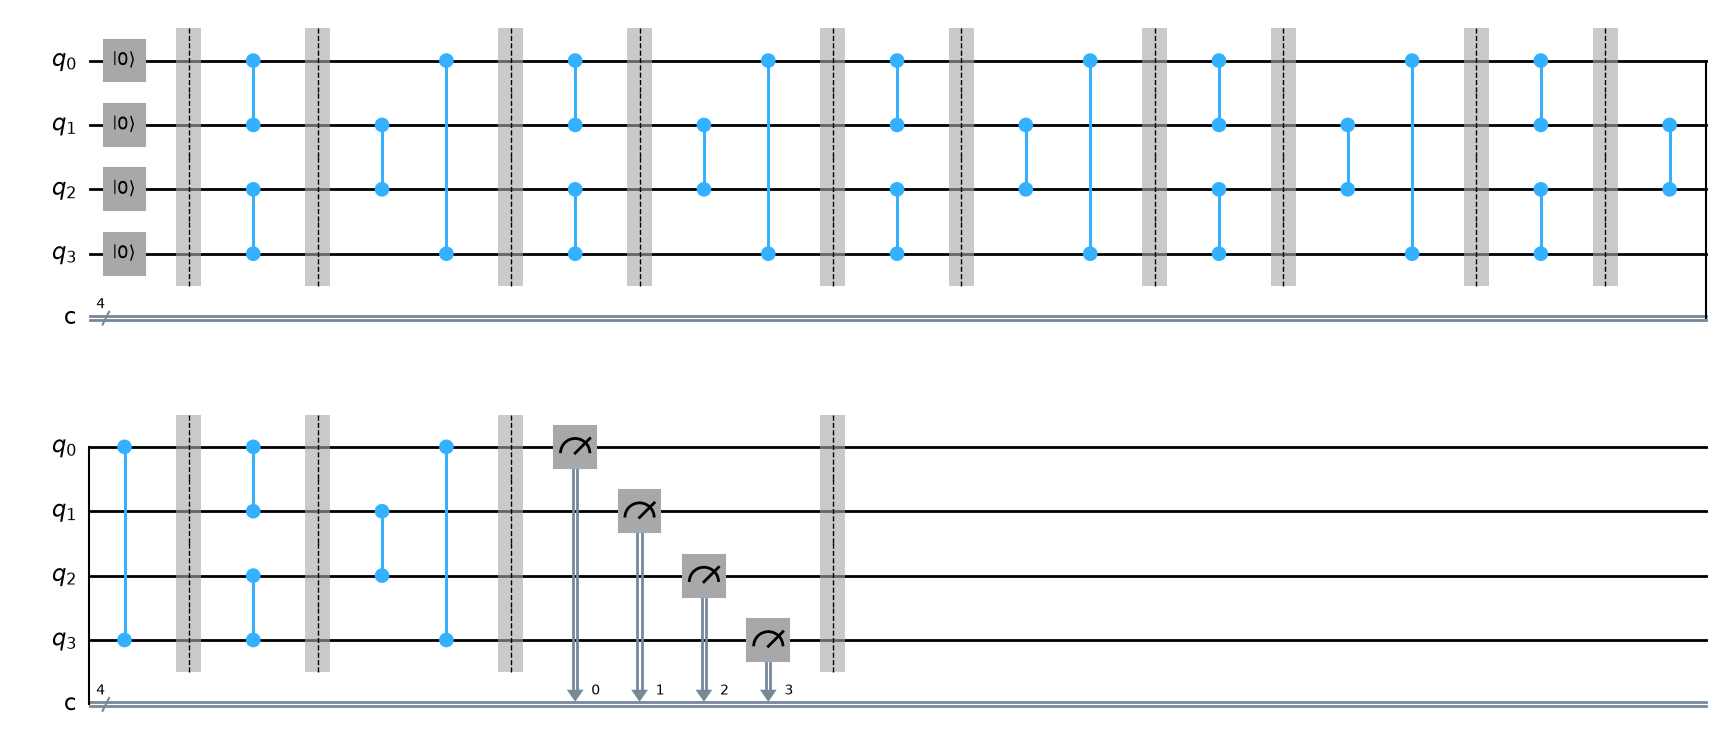

In [27]:
qc = QuantumCircuit(4,4)
qc.reset([0,1,2,3])
qc.barrier()
for dummy_idx in range(6):
    qc.cz(0,1)
    qc.cz(2,3)
    qc.barrier()
    qc.cz(1,2)
    qc.cz(0,3)
    qc.barrier()

qc.measure(0,0)
qc.measure(1,1)
qc.measure(2,2)
qc.measure(3,3)
qc.barrier()
qc.draw("mpl")

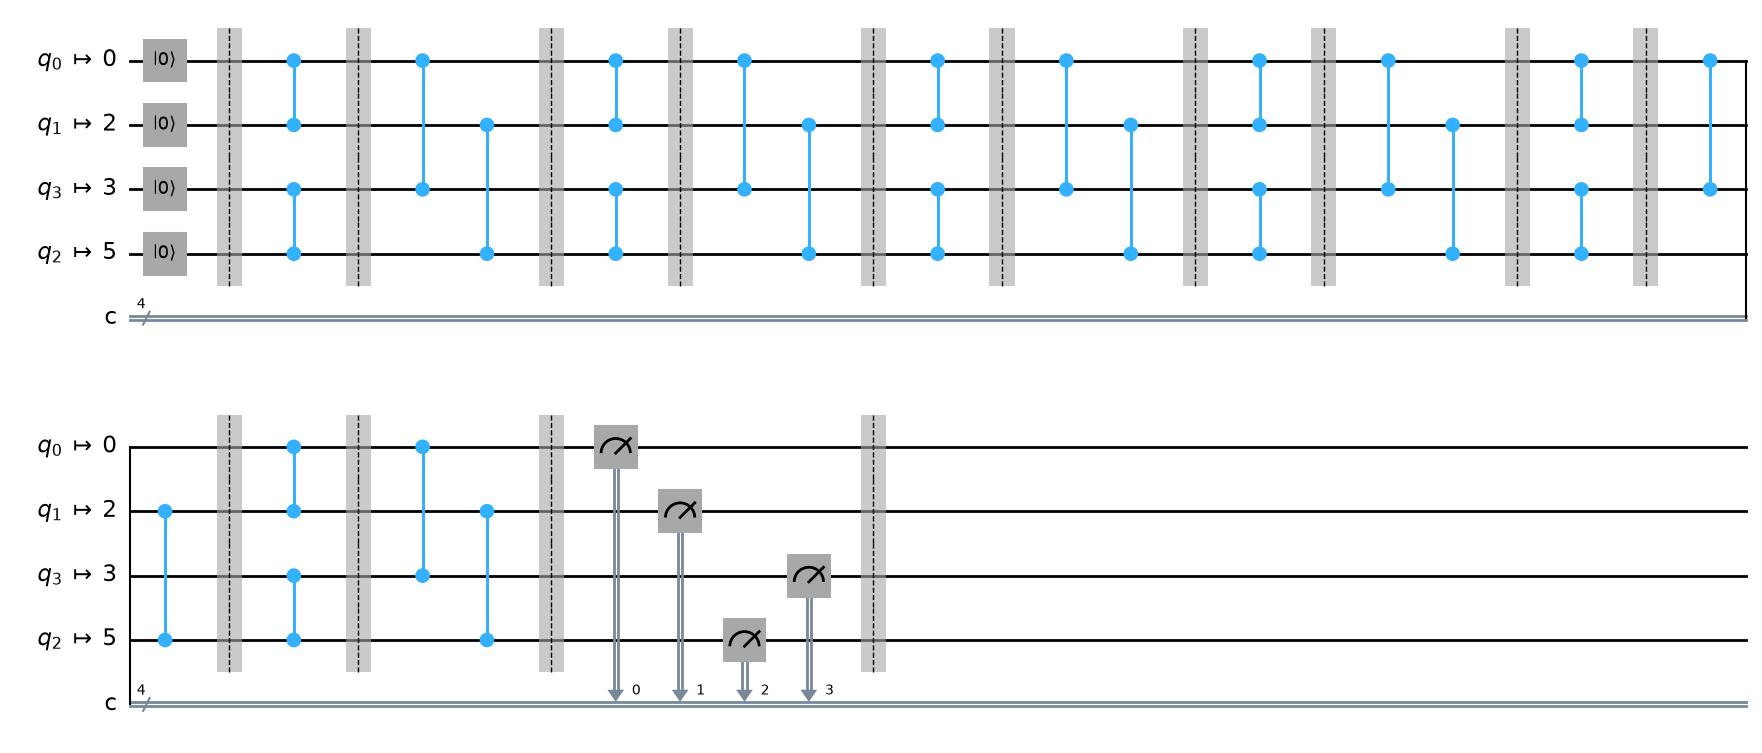

In [28]:
# the QI Tuna systems have the rz gate as an additional native gate, but the Starmon-7 simulator does not.
native_gates = ["id", "s", "sdg", "t", "tdg", "x", "rx", "y", "ry", "z", "cz", "delay", "reset", "measure"]
qc_transpiled = transpile(qc,
                          backend,
                          basis_gates=native_gates,
                          initial_layout=[0,2,5,3],
                          optimization_level=0)
qc_transpiled.draw('mpl')

One can learn the noise model parameters for this extra qubit pair, or just use the parameters provided below,

In [29]:
noise_model_parameters = { # in units of [1/s]
    "Qubit pair [0, 2]": {
            "XI": 42565.098340440454,
            "YI": 46226.78002823898,
            "ZI": 57864.11967535045,
            "IX": 38158.6807055183,
            "IY": 38478.02242420593,
            "IZ": 33256.417603906906,
            "XX": 36009.104138000905,
            "XY": 32708.597059315314,
            "XZ": 41947.047831649914,
            "YX": 33286.00519068634,
            "YY": 34848.95661473187,
            "YZ": 46796.94620486484,
            "ZX": 38459.99192199387,
            "ZY": 38197.38489242815,
            "ZZ": 78883.10049226432
         },
      "Qubit pair [3, 5]": {
            "XI": 47915.53380783515,
            "YI": 51810.550451721516,
            "ZI": 45627.49835842688,
            "IX": 55530.141777311015,
            "IY": 59945.568872066884,
            "IZ": 74411.43557939322,
            "XX": 49582.4406287242,
            "XY": 47000.74261901998,
            "XZ": 50061.48313172671,
            "YX": 49387.88776084952,
            "YY": 48033.75047674861,
            "YZ": 49593.94263279429,
            "ZX": 55689.604273706325,
            "ZY": 59800.16175599199,
            "ZZ": 90756.16867544502
         },
      "Qubit pair [0, 3]": {
            "XI": 42107.743725259854,
            "YI": 44174.7873310544,
            "ZI": 58105.977984037876,
            "IX": 37200.460175206914,
            "IY": 36691.10626063522,
            "IZ": 35282.72411450895,
            "XX": 32021.427518515415,
            "XY": 33241.688174489595,
            "XZ": 40233.35741721927,
            "YX": 33252.470529423226,
            "YY": 32810.05711205067,
            "YZ": 46049.84624729914,
            "ZX": 36482.64491758731,
            "ZY": 37324.73958034124,
            "ZZ": 77901.14607918797
         },
      "Qubit pair [2, 5]": {
            "XI": 43547.90091845381,
            "YI": 44385.21873167827,
            "ZI": 39517.2527564508,
            "IX": 53519.82850717707,
            "IY": 51580.80166854409,
            "IZ": 69048.82560227158,
            "XX": 43343.15052083891,
            "XY": 41445.79021111859,
            "XZ": 45036.31184866893,
            "YX": 43074.925990294556,
            "YY": 42768.01247636688,
            "YZ": 42863.174631506634,
            "ZX": 51395.55569962368,
            "ZY": 53831.65410118439,
            "ZZ": 84761.4021490045
         }
}

We can do noise amplification just as before, just make sure to now provide four qubits,

In [30]:
exp = NoiseAmplification(backend=backend,
                         transpiled_circuit=qc_transpiled,
                         qubit_list=[0,2,5,3],
                         )
raw_probabilities, ro_corrected_probabilities = exp.run(
    pauli_error_rates=noise_model_parameters,
    noise_levels=[1.0, 1.2, 1.6, 2.3],
)

ro_corrected_probabilities

Creating project directory
Creating circuits
Executing circuits


    Noise Levels:  100%|██████████| 4/4 [03:01<00:00, 45.38s/it]


{'G=1.0': [{'0000': np.float64(0.47595889730696006),
   '0001': np.float64(0.06004445650222294),
   '0010': np.float64(0.0777624592468524),
   '0011': np.float64(0.03249411203062904),
   '0100': np.float64(0.07689632888195348),
   '0101': np.float64(0.013121134290295025),
   '0110': np.float64(0.0398574813207258),
   '0111': np.float64(0.008224176517562364),
   '1000': np.float64(0.0824332463290915),
   '1001': np.float64(0.0336381524118935),
   '1010': np.float64(0.016936764678051577),
   '1011': np.float64(0.010083123143833807),
   '1100': np.float64(0.04487649786009611),
   '1101': np.float64(0.00937027483966873),
   '1110': np.float64(0.012642045319323185),
   '1111': np.float64(0.005660849320840502)}],
 'G=1.2': [{'0000': np.float64(0.415700169642056),
   '0001': np.float64(0.0666861824451695),
   '0010': np.float64(0.08432997283711026),
   '0011': np.float64(0.03737109223535242),
   '0100': np.float64(0.0796324769544793),
   '0101': np.float64(0.01785605510640947),
   '0110': np.

ZNE also works just as before, just make sure the observables act on four qubits,

In [31]:
zne = ZNE(exp.project_dir)
mitigated_expectation_values = zne.run(observables=[["ZIII","IZII","IIZI","IIIZ"]], method="auto")

mitigated_expectation_values

[{'ZIII': np.float64(0.9357670082847137),
  'IZII': np.float64(1.069351182831733),
  'IIZI': np.float64(0.9796629356504286),
  'IIIZ': np.float64(0.8575234921807374)}]

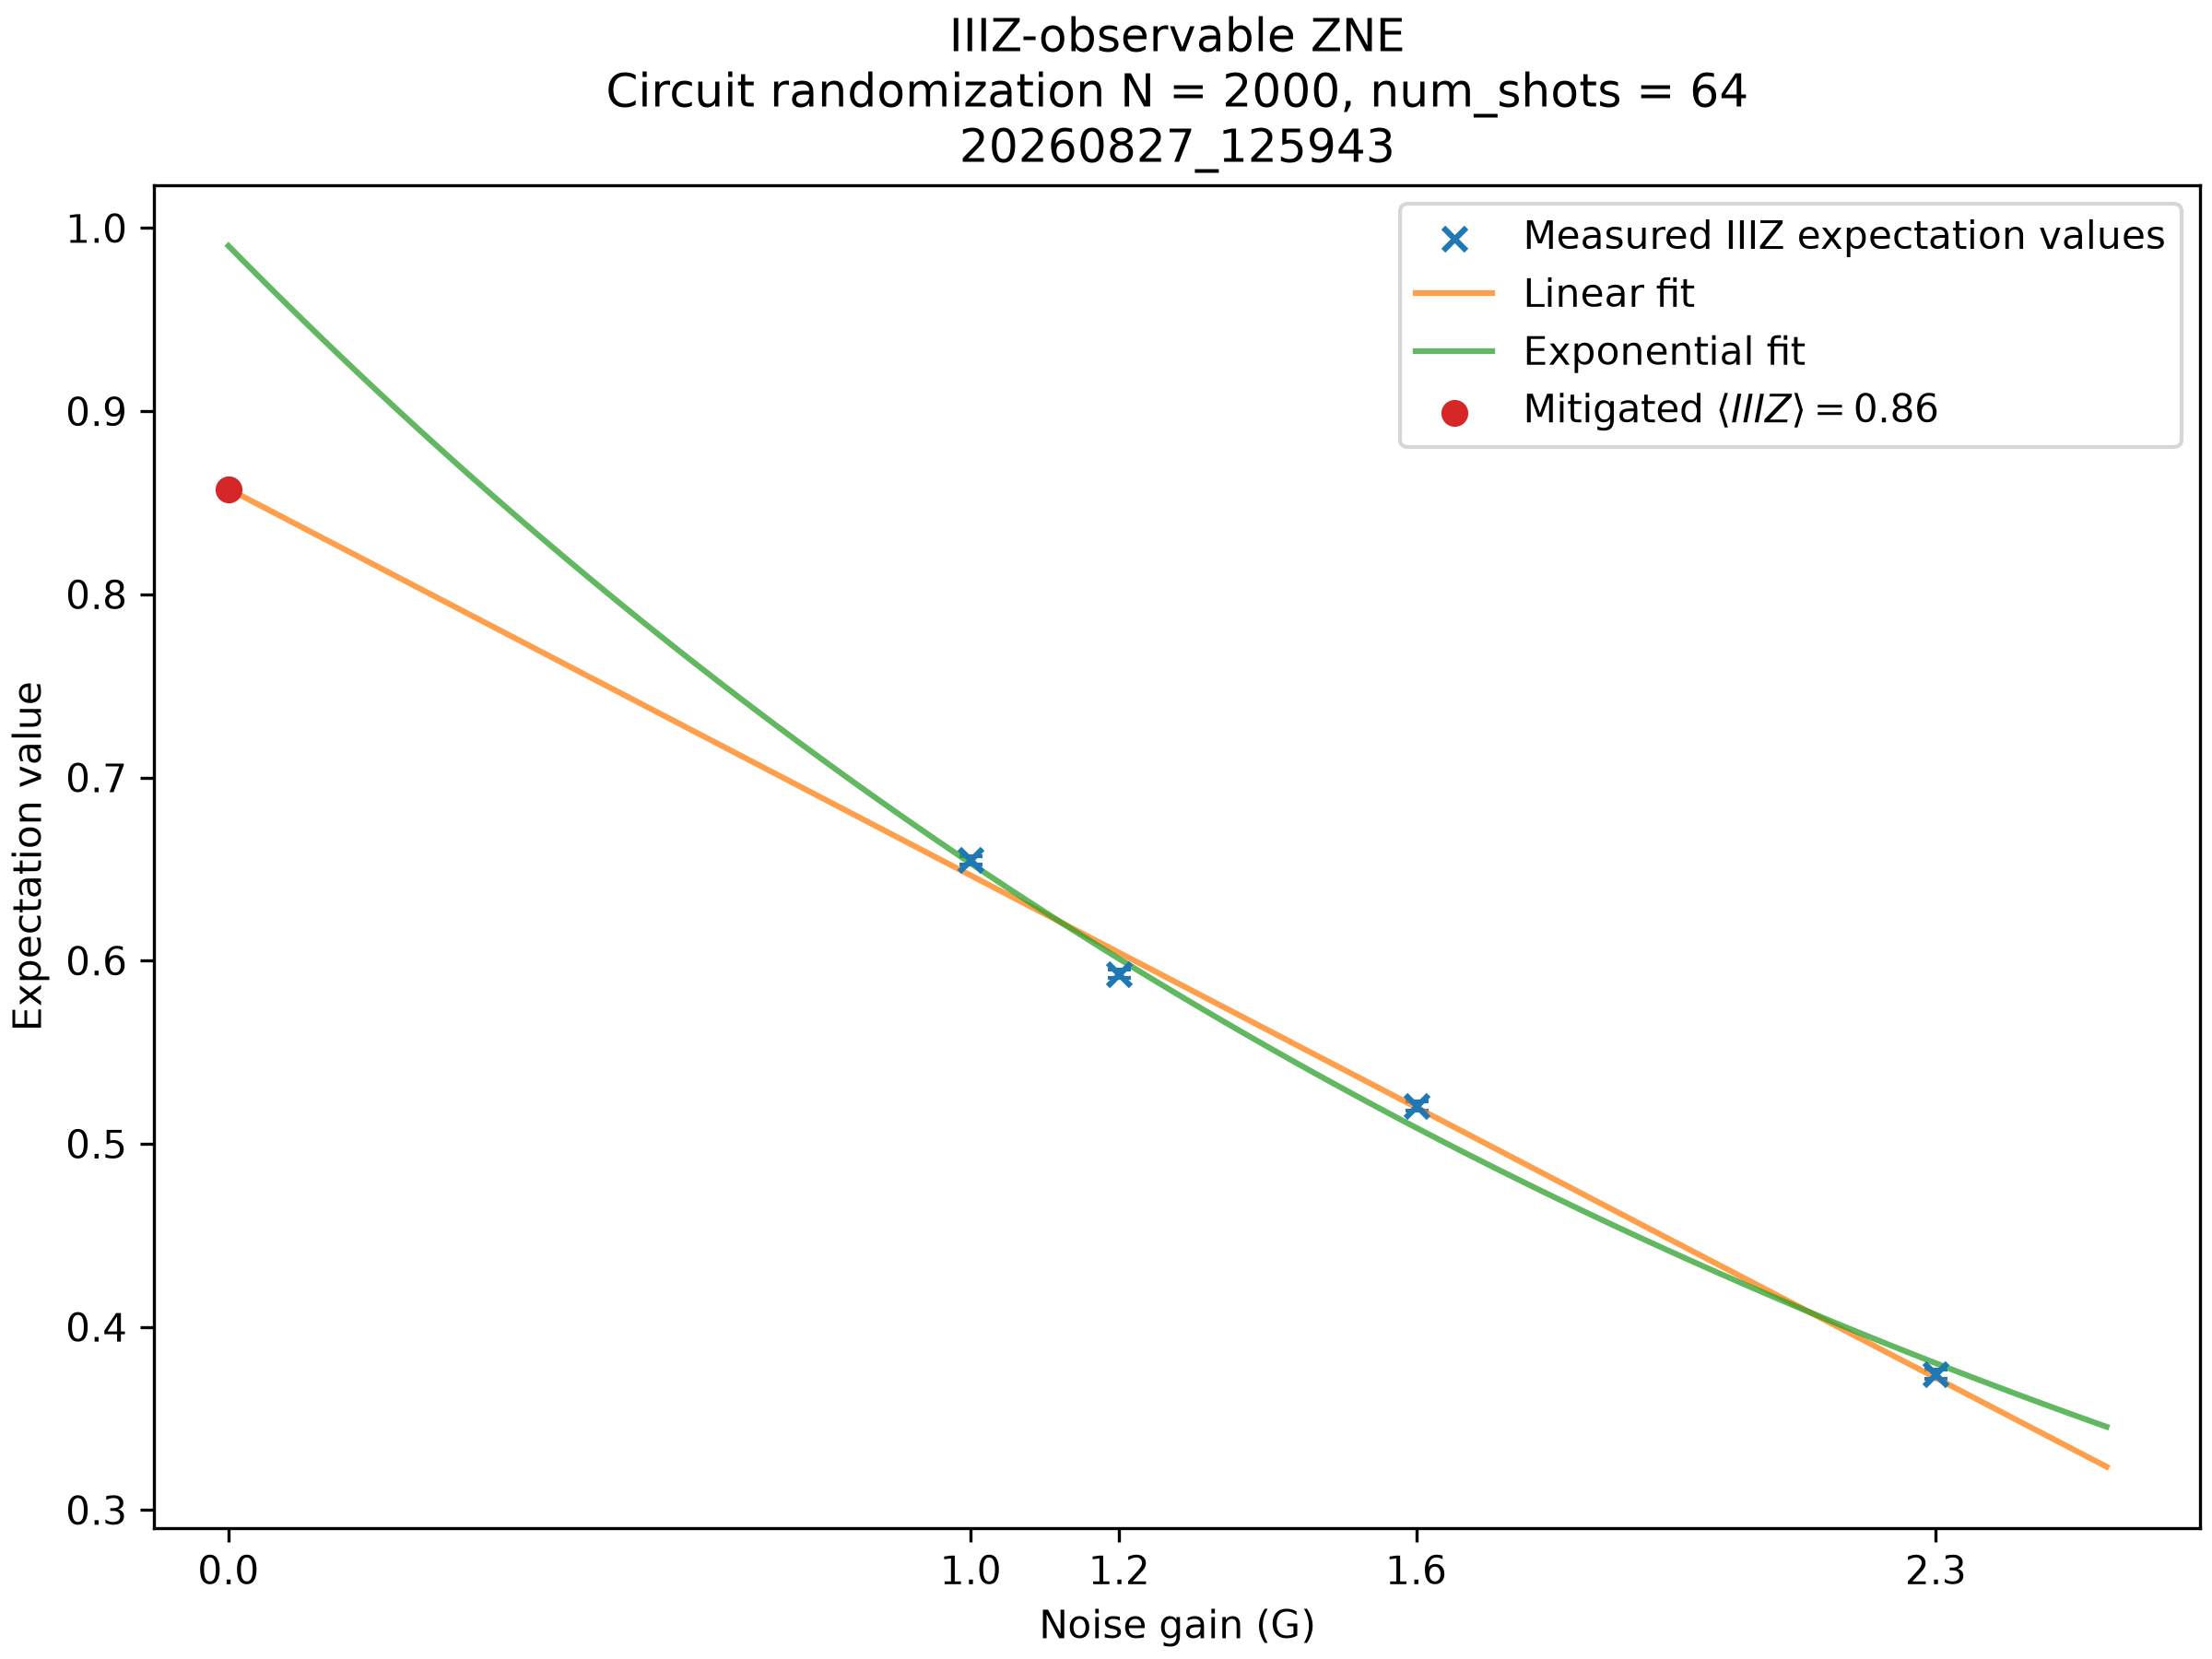

In [33]:
display(Image(zne.project_dir / "ZNE_figures" / f"IIIZ-observable_ZNE_{zne.timestamp}.png"))